In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_excel(r'C:\Users\Марьям\Downloads\Когортный анализ.xlsx')


print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704840 entries, 0 to 704839
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   user_id  704840 non-null  object        
 1   date     704840 non-null  datetime64[ns]
 2   price    704840 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 16.1+ MB
None


,user_id,date,price
0,A0005,2020-03-25,50
1,A0005,2020-03-25,40
2,A0005,2020-03-26,70
3,A0005,2020-03-27,20
4,A0005,2020-03-29,50


In [6]:
df['order_month'] = df['date'].dt.to_period('M')

df['cohort'] = df.groupby('user_id')['date'].transform('min').dt.to_period('M')

In [7]:
cohort_users = df.groupby(['cohort', 'order_month']).agg(n_customers=('user_id', 'nunique')).reset_index()
cohort_users['period_number'] = (cohort_users.order_month - cohort_users.cohort).apply(lambda x: x.n)


retention_pivot = cohort_users.pivot_table(index='cohort', columns='period_number', values='n_customers')
retention_matrix = retention_pivot.divide(retention_pivot.iloc[:, 0], axis=0)

In [8]:
cohort_revenue = df.groupby(['cohort', 'order_month']).agg(total_revenue=('price', 'sum')).reset_index()
cohort_revenue['period_number'] = (cohort_revenue.order_month - cohort_revenue.cohort).apply(lambda x: x.n)

revenue_pivot = cohort_revenue.pivot_table(index='cohort', columns='period_number', values='total_revenue')

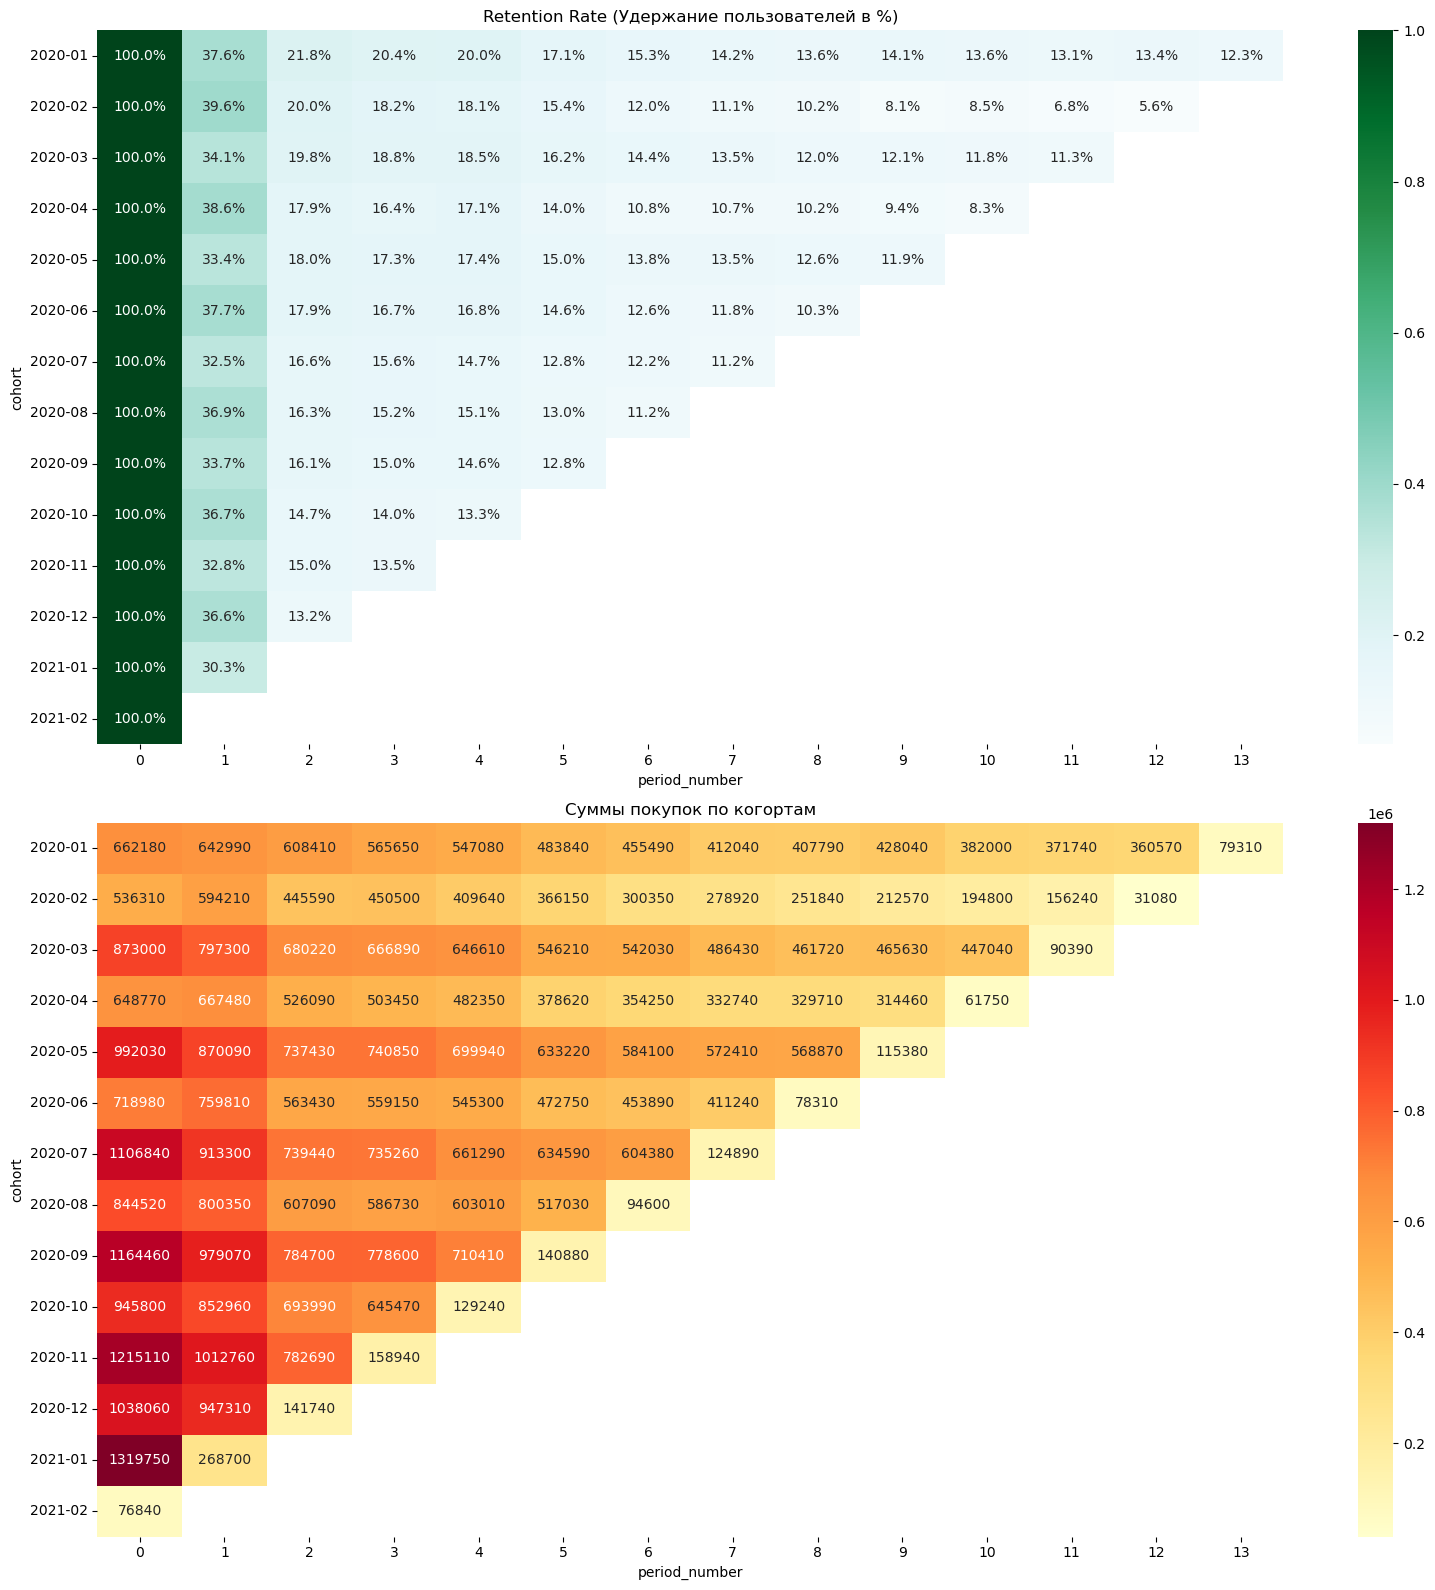

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(16, 16))

sns.heatmap(retention_matrix, annot=True, fmt='.1%', cmap='BuGn', ax=ax[0])
ax[0].set_title('Retention Rate (Удержание пользователей в %)')


sns.heatmap(revenue_pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax[1])
ax[1].set_title('Суммы покупок по когортам')

plt.tight_layout()
plt.show()

Выводы по анализу:
1. Retention Rate (Удержание): * Лучшая возвращаемость во второй месяц (период 1) наблюдается у когорты 2020-02 (39.6%).
• Худшие показатели удержания на старте у когорты 2020-07 (32.5%).
• В целом видна общая тенденция к снижению активности пользователей с течением времени («затухание» цвета к правому краю).
2. Суммы заказов:
• Самая прибыльная когорта в первый месяц — 2021-01 (сумма 1 319 750), что значительно выше показателей начала 2020 года.
• Заметно, что суммы покупок со временем падают медленнее, чем количество активных людей. Это может значить, что «ядро» лояльных клиентов совершает более дорогие покупки.
3. Что исследовать дальше:
• Стоит проверить, почему в когорте 2020-02 люди возвращались лучше всего (была ли это удачная акция или сезонность).